# Time-Series Forecasting with ARIMA

End-to-end reproducible daily demand forecasting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/raw/daily-demand-series.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

Shape: (30, 4)
Columns: ['date', 'demand', 'marketing_event', 'holiday']


In [3]:
date_col = 'date'
demand_col = 'demand'

ts = df[[date_col, demand_col]].copy()
ts[date_col] = pd.to_datetime(ts[date_col])
ts[demand_col] = pd.to_numeric(ts[demand_col])
ts = ts.sort_values(date_col).drop_duplicates(date_col)
ts = ts.set_index(date_col)[demand_col].asfreq('D')
ts = ts.interpolate().ffill().bfill()
ts

date
2026-06-01    118
2026-06-02    121
2026-06-03    125
2026-06-04    123
2026-06-05    137
2026-06-06    151
2026-06-07    143
2026-06-08    126
2026-06-09    129
2026-06-10    132
2026-06-11    135
2026-06-12    148
2026-06-13    160
2026-06-14    146
2026-06-15    131
2026-06-16    134
2026-06-17    139
2026-06-18    141
2026-06-19    154
2026-06-20    168
2026-06-21    152
2026-06-22    137
2026-06-23    140
2026-06-24    144
2026-06-25    147
2026-06-26    161
2026-06-27    174
2026-06-28    158
2026-06-29    143
2026-06-30    146
Freq: D, Name: demand, dtype: int64

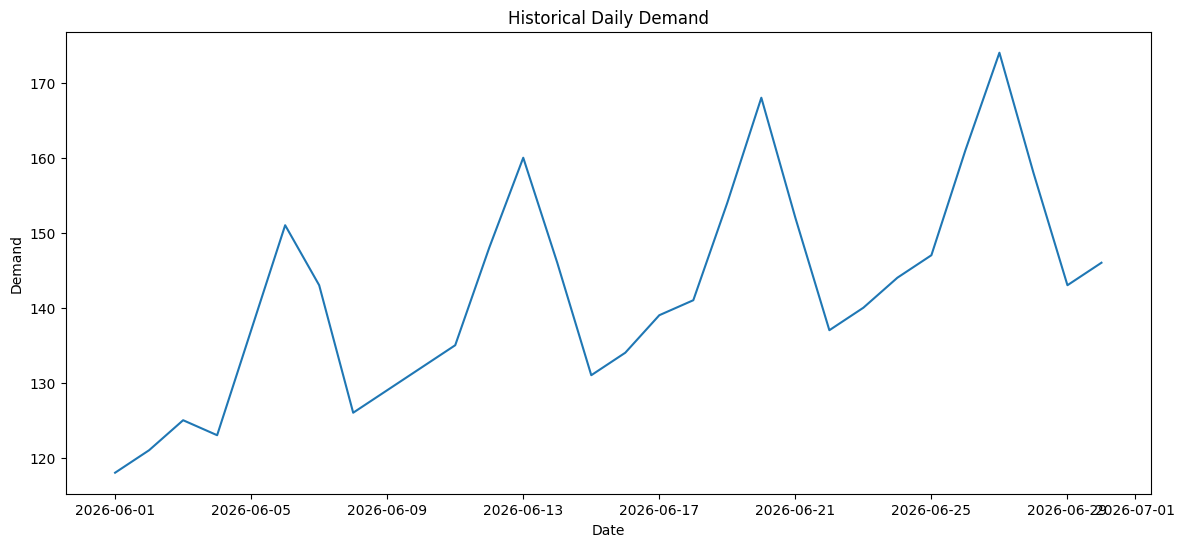

In [4]:
plt.figure(figsize=(14,6))
plt.plot(ts)
plt.title('Historical Daily Demand')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.show()

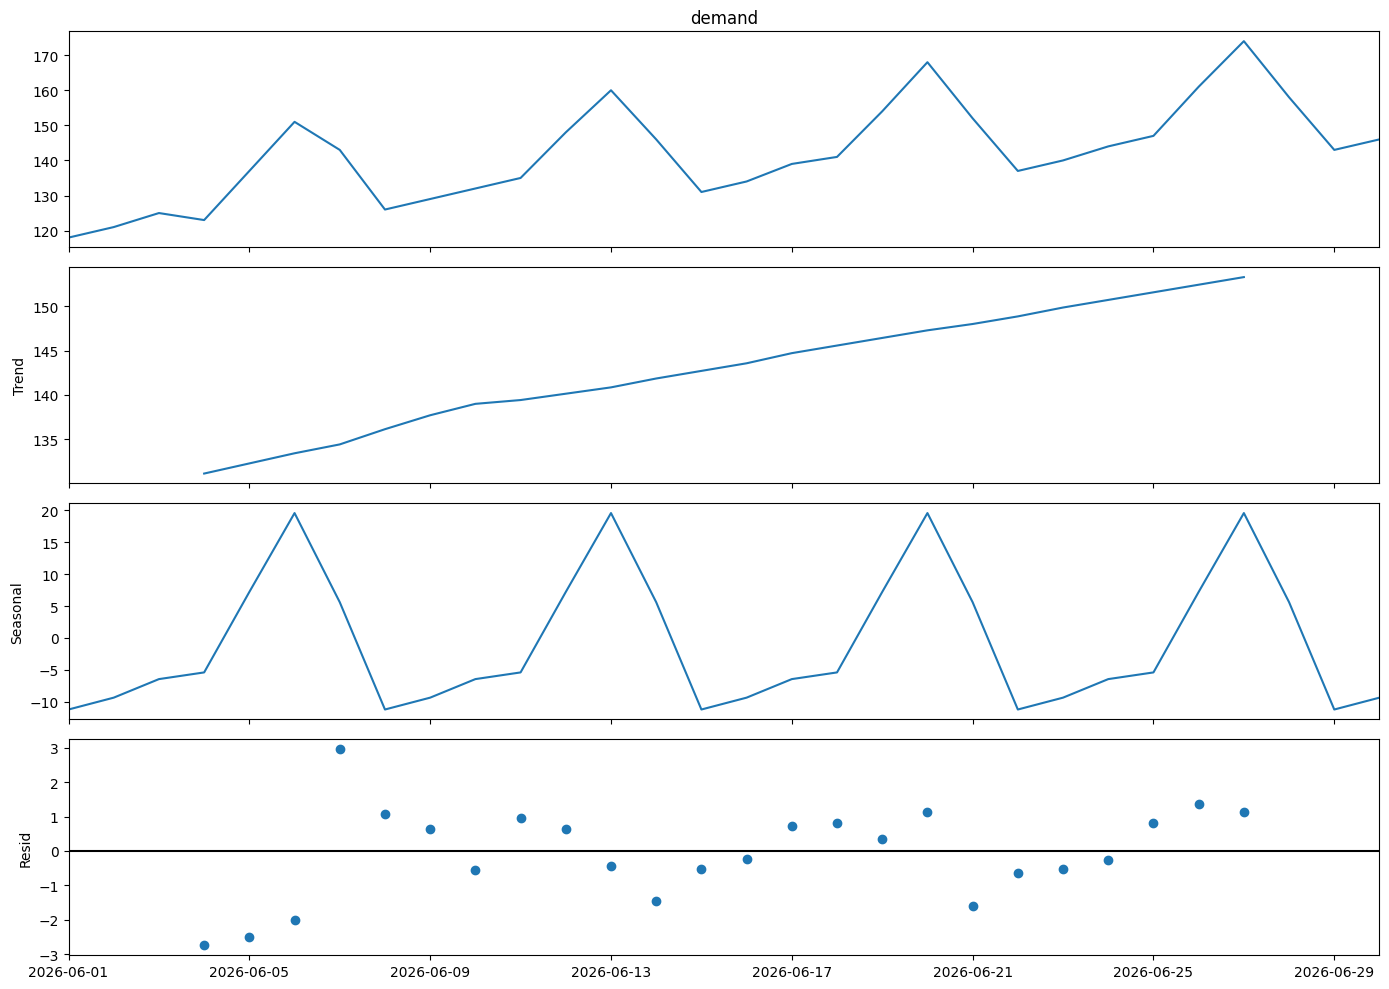

In [5]:
decomp = seasonal_decompose(ts, model='additive', period=7)
fig = decomp.plot()
fig.set_size_inches(14,10)
plt.tight_layout()
plt.show()

In [6]:
adf_original = adfuller(ts)
print('Original ADF:', adf_original[0])
print('Original p-value:', adf_original[1])

diff = ts.diff().dropna()
adf_diff = adfuller(diff)
print('Differenced ADF:', adf_diff[0])
print('Differenced p-value:', adf_diff[1])

Original ADF: -0.9038698873856347
Original p-value: 0.7866953368372339
Differenced ADF: -2.2336240127354112
Differenced p-value: 0.19426893706635717


In [7]:
test_size = 15
train = ts.iloc[:-test_size]
test = ts.iloc[-test_size:]
print('Train observations:', len(train))
print('Test observations:', len(test))

Train observations: 15
Test observations: 15


In [8]:
orders = [(0, 1, 0), (0, 1, 1), (1, 1, 0), (1, 1, 1), (1, 1, 2), (2, 1, 0), (2, 1, 1), (2, 1, 2)]
results = []
for order in orders:
    try:
        fit = ARIMA(train, order=order).fit()
        results.append({'order': order, 'AIC': fit.aic})
    except Exception:
        pass
results = pd.DataFrame(results).sort_values('AIC')
results

,order,AIC
5,"(2, 1, 0)",105.155342
1,"(0, 1, 1)",105.245964
6,"(2, 1, 1)",106.047330
4,"(1, 1, 2)",106.589729
3,"(1, 1, 1)",107.156909
7,"(2, 1, 2)",107.252077
0,"(0, 1, 0)",107.491476
2,"(1, 1, 0)",108.413304


In [9]:
best_order = tuple(results.iloc[0]['order'])
print('Selected ARIMA:', best_order)

Selected ARIMA: (2, 1, 0)


In [10]:
fit = ARIMA(train, order=best_order).fit()
pred = fit.forecast(steps=15)
pred.index = test.index
rmse = np.sqrt(mean_squared_error(test, pred))
mask = test.values != 0
mape_value = np.mean(np.abs((test.values[mask] - pred.values[mask]) / test.values[mask])) * 100
print('MAPE:', mape_value)
print('RMSE:', rmse)

MAPE: 6.876135721541692
RMSE: 14.82530948633336


In [11]:
final_fit = ARIMA(ts, order=best_order).fit()
future = final_fit.forecast(steps=30)
future.index = pd.date_range(ts.index.max() + pd.Timedelta(days=1), periods=30, freq='D')
forecast = pd.DataFrame({'date': future.index, 'forecast_demand': future.values})
forecast

,date,forecast_demand
0,2026-07-01,155.944108
1,2026-07-02,158.017115
2,2026-07-03,152.989470
3,2026-07-04,149.838142
4,2026-07-05,151.569856
5,2026-07-06,154.083302
6,2026-07-07,154.036934
7,2026-07-08,152.546453
8,2026-07-09,151.999454
9,2026-07-10,152.662004


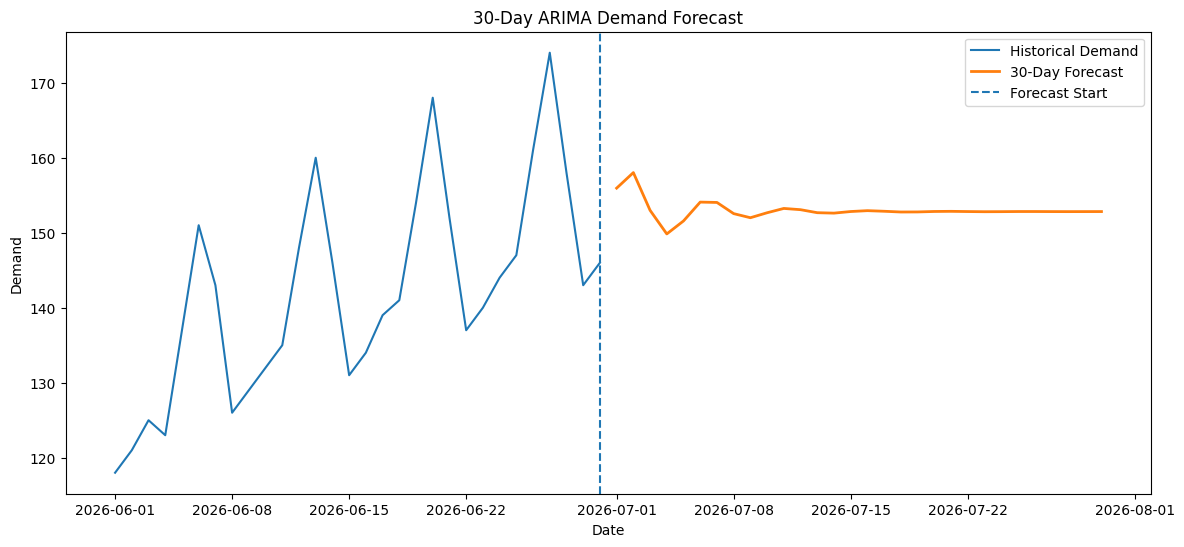

In [12]:
plt.figure(figsize=(14,6))
plt.plot(ts, label='Historical Demand')
plt.plot(future, label='30-Day Forecast', linewidth=2)
plt.axvline(ts.index.max(), linestyle='--', label='Forecast Start')
plt.title('30-Day ARIMA Demand Forecast')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.show()

## Evaluation Results

Selected model: **ARIMA(2, 1, 0)**

Holdout MAPE: **6.876%**

Holdout RMSE: **14.825**